<a href="https://colab.research.google.com/github/madhankumarm2408-sketch/Future_ML_01/blob/main/Sales_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')


In [5]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
print(df.head())
print(df.shape)
print(df.columns.tolist())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [6]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(9994, 21)
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [7]:
print(df.head(5))
print(df['Order Date'].head(5))

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [8]:
print(df['Sales'].describe())
print(df['Category'].unique())
print(df['Segment'].unique())

count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: Sales, dtype: float64
['Furniture' 'Office Supplies' 'Technology']
['Consumer' 'Corporate' 'Home Office']


In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Year'] = df['Order Date'].dt.to_period('M')

print(df[['Order Date', 'Year','Month', 'Month_Year']].head())
print("/n Years in dataset:", sorted(df['Year'].unique()))
print("Total months of the data", df['Month_Year'].nunique())

  Order Date  Year  Month Month_Year
0 2016-11-08  2016     11    2016-11
1 2016-11-08  2016     11    2016-11
2 2016-06-12  2016      6    2016-06
3 2015-10-11  2015     10    2015-10
4 2015-10-11  2015     10    2015-10
/n Years in dataset: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]
Total months of the data 48


In [10]:
monthly_sales = df.groupby('Month_Year')['Sales'].sum().reset_index()
monthly_sales.columns = ['Month_Year', 'Total_Sales']
monthly_sales['Month_Year_str'] = monthly_sales['Month_Year'].astype(str)
print(monthly_sales)

   Month_Year  Total_Sales Month_Year_str
0     2014-01   14236.8950        2014-01
1     2014-02    4519.8920        2014-02
2     2014-03   55691.0090        2014-03
3     2014-04   28295.3450        2014-04
4     2014-05   23648.2870        2014-05
5     2014-06   34595.1276        2014-06
6     2014-07   33946.3930        2014-07
7     2014-08   27909.4685        2014-08
8     2014-09   81777.3508        2014-09
9     2014-10   31453.3930        2014-10
10    2014-11   78628.7167        2014-11
11    2014-12   69545.6205        2014-12
12    2015-01   18174.0756        2015-01
13    2015-02   11951.4110        2015-02
14    2015-03   38726.2520        2015-03
15    2015-04   34195.2085        2015-04
16    2015-05   30131.6865        2015-05
17    2015-06   24797.2920        2015-06
18    2015-07   28765.3250        2015-07
19    2015-08   36898.3322        2015-08
20    2015-09   64595.9180        2015-09
21    2015-10   31404.9235        2015-10
22    2015-11   75972.5635        

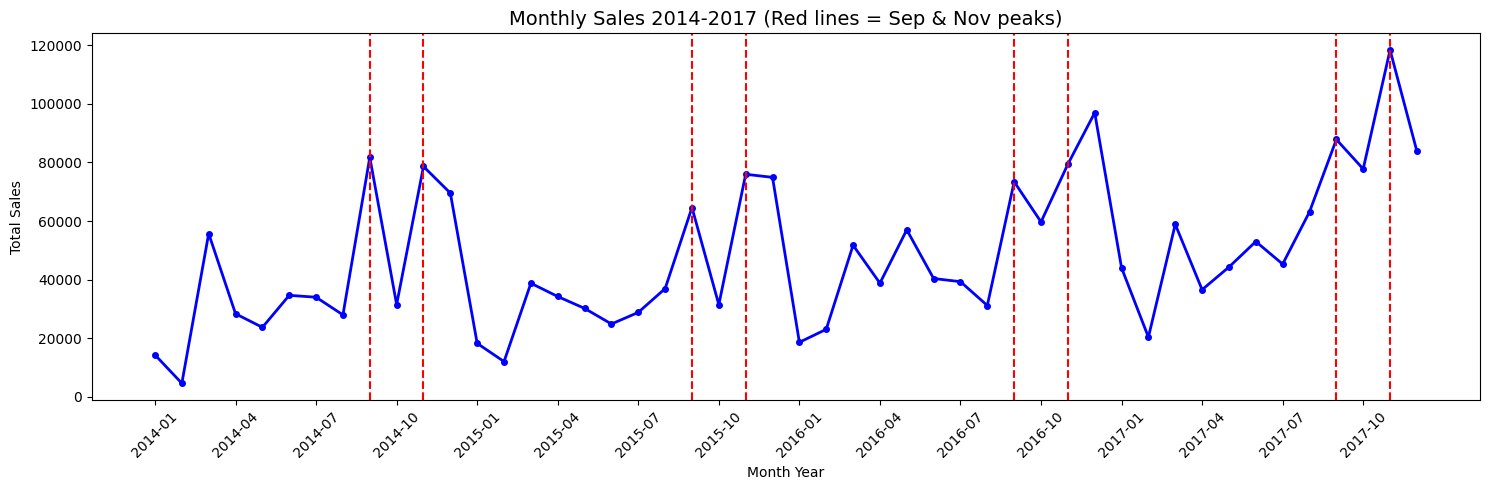

In [11]:
plt.figure(figsize=(15,5))
plt.plot(monthly_sales['Month_Year_str'], monthly_sales['Total_Sales'], marker='o', linewidth=2, color='blue', markersize=4)

for i, row in monthly_sales.iterrows():
  if '-09' in row['Month_Year_str'] or '-11' in row['Month_Year_str']:
      plt.axvline(x=i, color='red', linestyle='--')

plt.xticks(range(0,48,3),monthly_sales['Month_Year_str'][::3], rotation=45)
plt.title('Monthly Sales 2014-2017 (Red lines = Sep & Nov peaks)',
          fontsize=14)

plt.xlabel('Month Year')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('sales_trend.png', dpi=150)
plt.show()

In [12]:
monthly_sales['Time_Index'] = range(len(monthly_sales))
monthly_sales['Month_Num'] = monthly_sales['Month_Year'].dt.month
monthly_sales['Year_Num'] = monthly_sales['Month_Year'].dt.year
print(monthly_sales[['Month_Year_str', 'Time_Index','Month_Num', 'Year_Num','Total_Sales']].head(10))

  Month_Year_str  Time_Index  Month_Num  Year_Num  Total_Sales
0        2014-01           0          1      2014   14236.8950
1        2014-02           1          2      2014    4519.8920
2        2014-03           2          3      2014   55691.0090
3        2014-04           3          4      2014   28295.3450
4        2014-05           4          5      2014   23648.2870
5        2014-06           5          6      2014   34595.1276
6        2014-07           6          7      2014   33946.3930
7        2014-08           7          8      2014   27909.4685
8        2014-09           8          9      2014   81777.3508
9        2014-10           9         10      2014   31453.3930


In [13]:
features = ['Time_Index', 'Month_Num', 'Year_Num']
target = 'Total_Sales'
X = monthly_sales[features]
y = monthly_sales[target]

X_train = X[:40]
y_train = y[:40]

X_test = X[40:]
y_test = y[40:]

print(f"Training data: {X_train.shape[0]} months")
print(f"Testing data: {X_test.shape[0]} months")
print(f"\nTest period covers:")
print(monthly_sales['Month_Year_str'][40:].values)

Training data: 40 months
Testing data: 8 months

Test period covers:
['2017-05' '2017-06' '2017-07' '2017-08' '2017-09' '2017-10' '2017-11'
 '2017-12']


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained")
print(f"\nWhat the model learned:")
print(f"Base sales (intercept): ${model.intercept_:,.2f}")
print(f"\nImpact of each feature:")
for feature, coef in zip(features, model.coef_):
  print(f"  {feature}: {coef:,.2f}")

Model trained

What the model learned:
Base sales (intercept): $628,749.20

Impact of each feature:
  Time_Index: 540.93
  Month_Num: 4,245.39
  Year_Num: -308.71


In [15]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    'Month': monthly_sales['Month_Year_str'][40:].values,
    'Actual_Sales': y_test.values,
    'Predicted_Sales': y_pred.round(2),
    'Difference': (y_test.values - y_pred).round(2)
})

print(results.to_string(index=False))


  Month  Actual_Sales  Predicted_Sales  Difference
2017-05    44261.1102         48954.78    -4693.67
2017-06    52981.7257         53741.11     -759.38
2017-07    45264.4160         58527.43   -13263.01
2017-08    63120.8880         63313.76     -192.87
2017-09    87866.6520         68100.08    19766.57
2017-10    77776.9232         72886.41     4890.52
2017-11   118447.8250         77672.73    40775.09
2017-12    83829.3188         82459.06     1370.26


In [17]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = (abs((y_test.values - y_pred) / y_test.values).mean()) * 100

print(f"Model Accuracy metrics")
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:,.1f}%")
print(f'/nModel is onaverage {mape:.1f}% off from actual sales')

Model Accuracy metrics
MAE: 10,713.92
RMSE: 16,873.32
MAPE: 13.3%
/nModel is onaverage 13.3% off from actual sales


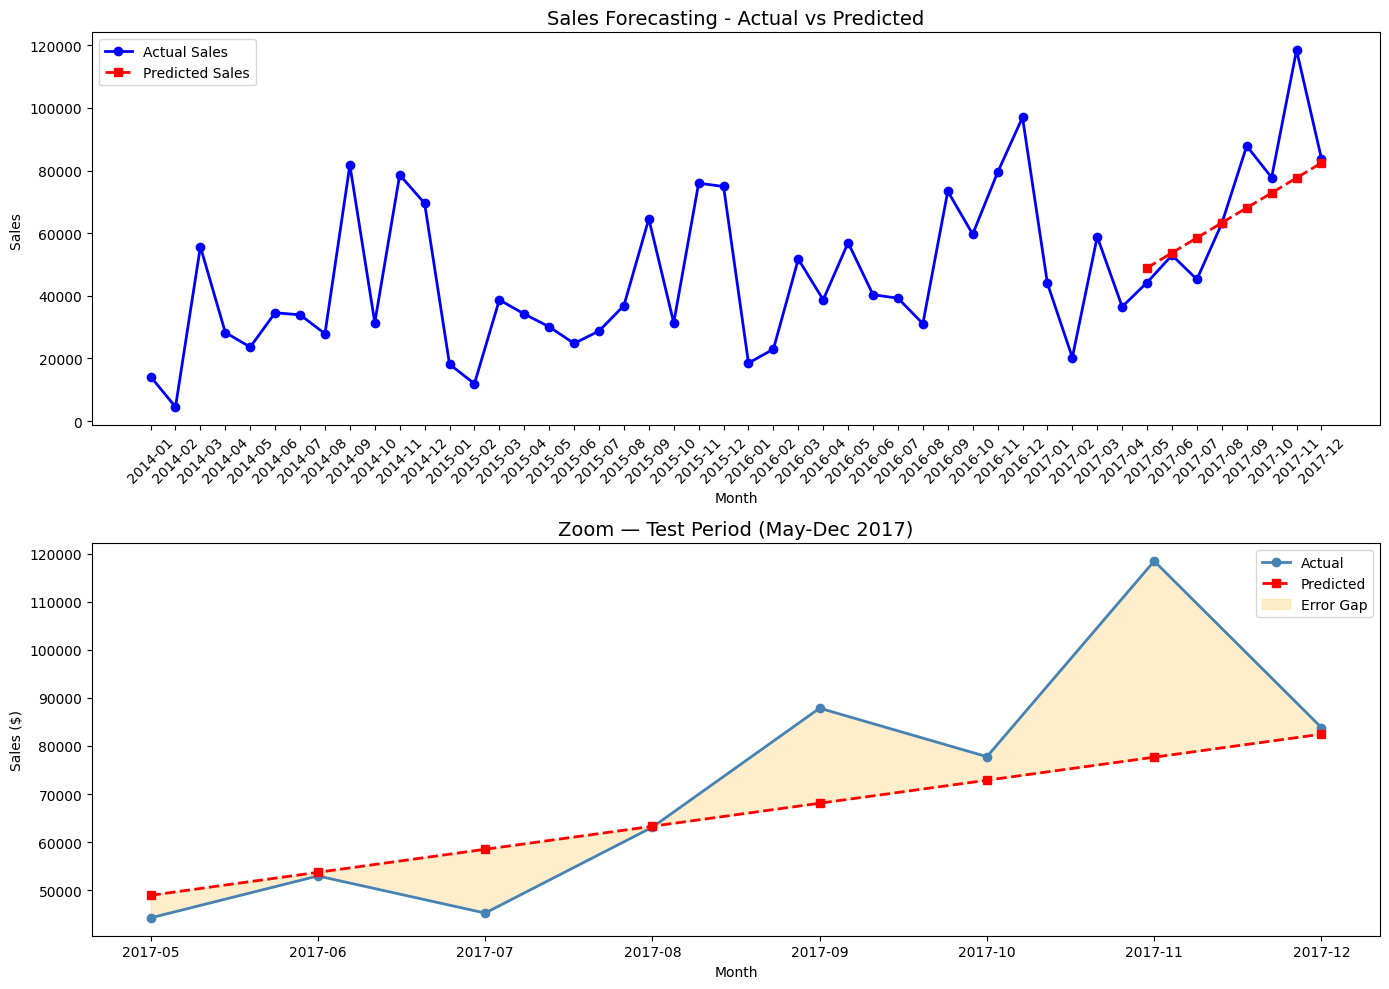

In [20]:
fig, axes = plt.subplots(2,1, figsize=(14,10))

axes[0].plot(monthly_sales['Month_Year_str'],
             monthly_sales['Total_Sales'],
             marker='o', label='Actual Sales',
             color='blue', linewidth=2)

axes[0].plot(results['Month'],
             results['Predicted_Sales'],
             marker='s', label='Predicted Sales',
             color='red', linewidth=2, linestyle='--')
axes[0].set_title('Sales Forecasting - Actual vs Predicted', fontsize=14)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Sales ')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(results['Month'], results['Actual_Sales'],
             marker='o', label='Actual', color='steelblue', linewidth=2)
axes[1].plot(results['Month'], results['Predicted_Sales'],
             marker='s', label='Predicted', color='red',
             linewidth=2, linestyle='--')
axes[1].fill_between(results['Month'],
                      results['Actual_Sales'],
                      results['Predicted_Sales'],
                      alpha=0.2, color='orange', label='Error Gap')
axes[1].set_title('Zoom — Test Period (May-Dec 2017)', fontsize=14)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Sales ($)')
axes[1].legend()

plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=150)
plt.show()


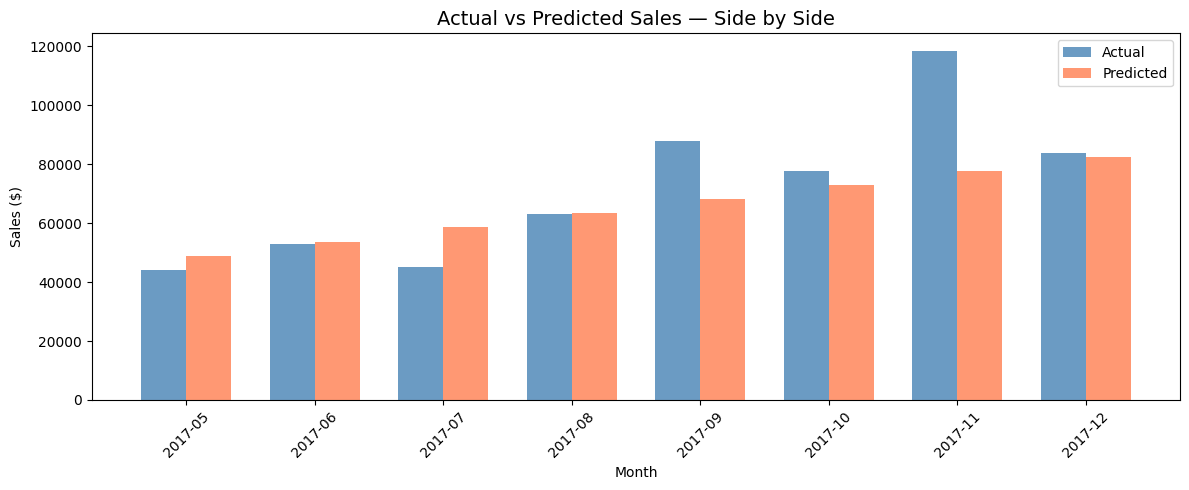

Bar chart saved!


In [21]:
x = range(len(results))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar([i - width/2 for i in x], results['Actual_Sales'],
                width, label='Actual', color='steelblue', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], results['Predicted_Sales'],
                width, label='Predicted', color='coral', alpha=0.8)

ax.set_title('Actual vs Predicted Sales — Side by Side', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Sales ($)')
ax.set_xticks(x)
ax.set_xticklabels(results['Month'], rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('bar_comparison.png', dpi=150)
plt.show()
print("Bar chart saved!")

In [22]:
results.to_csv('sales_forecast_results.csv', index=False)
monthly_sales.to_csv('monthly_sales_data.csv', index=False)
print("Files saved successfully!")

# Final summary
print(f"\n{'='*50}")
print(f"PROJECT COMPLETE — SUMMARY")
print(f"{'='*50}")
print(f"Total months analysed: 48")
print(f"Model accuracy: {100-13.3:.1f}%")
print(f"Charts saved: sales_trend.png, predictions_vs_actual.png, bar_comparison.png")
print(f"Data saved: sales_forecast_results.csv")

Files saved successfully!

PROJECT COMPLETE — SUMMARY
Total months analysed: 48
Model accuracy: 86.7%
Charts saved: sales_trend.png, predictions_vs_actual.png, bar_comparison.png
Data saved: sales_forecast_results.csv
